In [34]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df=pd.read_csv("../data/data.csv", header=None)

In [35]:
def predict(x, w, b):
    return x*w+b

def compute_loss(y_hat, y, delta=5):
    if abs(y_hat - y)<delta:
        loss = 0.5*(y_hat - y)*(y_hat - y)
    else: 
        loss = delta*abs(y_hat-y) - 0.5*delta*delta
    return loss

def grad_MSE(x, y_hat, y):
    dw=x*(y_hat-y)
    db=y_hat-y
    return (dw, db)

def grad_MAE(x, y_hat, y, delta=5):
    dw = delta*x*(y_hat-y)/abs(y_hat-y)
    db = delta*(y_hat-y)/abs(y_hat-y)
    
    return (dw, db)

def gradient_compute(y_hat, y, x, delta=5):
    if abs(y_hat - y)<delta:
        dw, db = grad_MSE(x, y_hat, y) 
    else: 
        dw, db= grad_MAE(x, y_hat, y, delta=5)
    return (dw, db)

def update_weight(w, b, lr, dw, db):
    w_new=w-lr*dw
    b_new=b-lr*db
    return (w_new, b_new)

In [36]:
def plot_chart(w, b, x_values, y_values):
    line_x = [min(x_values) - 1, max(x_values) + 1]
    line_y = [predict(x, w, b) for x in line_x]

    plt.figure(figsize=(6, 4))
    plt.scatter(x_values, y_values, color="blue")
    plt.plot(line_x, line_y, color="red")

    equation = f"y = {w:.2f}x + {b:.2f}"
    plt.text(line_x[0] + 0.2, line_y[0] + 1, equation, color="red")

    plt.xlim(min(x_values) - 0.5, max(x_values) + 0.5)
    plt.ylim(min(y_values) - 5, max(y_values) + 5)
    plt.show()

def one_sample_training_using_huber_loss():
    # Initialization
    b = 0.4
    w=-0.34
    lr=0.01
    
    # How long
    epoch_max=10
    data_size=4
    
    # Training Data
    X_values=df.iloc[:, 0].to_numpy()
    y_values=df.iloc[:, 1].to_numpy()
    losses=[]

    for epoch in range(epoch_max):
        for i in range(data_size):
            x=X_values[i]
            y=y_values[i]

            y_hat=predict(x, w, b)
            
            dw, db=gradient_compute(y_hat, y, x)
            
            w, b = update_weight(w, b, lr, dw, db)

            loss=compute_loss(y_hat, y)
            losses.append(loss)
    plot_chart(w, b, X_values, y_values)
    plt.plot(losses)
    plt.show()

In [37]:
def mini_batch_training(m=2):
    # Initialization
    b = 0.04
    w=-0.34
    lr=0.01
    # How long
    epoch_max=30
    data_size=8
    # Training Data
    X_values = [1, 2, 3, 4, 5, 6, 7, 8]
    y_values = [2, 3, 4, 5, 6, 7, 8, 40]
    N=4
    losses=[]
    # Implementation
    for _ in range(epoch_max):
        for i in range(0, N, m):
            dw, db = [], []
            loss_total=0
            for j in range(m):
                X=X_values[i+j]
                y=y_values[i+j]

                y_hat=predict(X, w, b)
                loss_total+=compute_loss(y_hat, y)
                
                grad_w, grad_b = gradient_compute(y_hat, y, X)
                dw.append(grad_w)
                db.append(grad_b)

            losses.append(loss_total/m)
            combined_dw=sum(dw)/m
            combined_db=sum(db)/m
            w, b = update_weight(w, b, lr, combined_dw, combined_db)
    plot_chart(w, b, X_values, y_values)
    print(losses[:5])
    plt.plot(losses)
    plt.show()
    

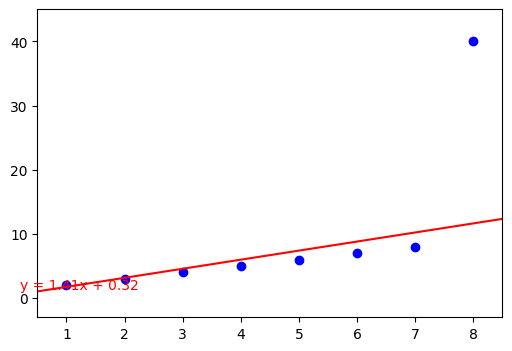

[42.396249999999995, 37.4850716978125, 32.78268336782337, 28.433075894888407, 24.752080078287328]


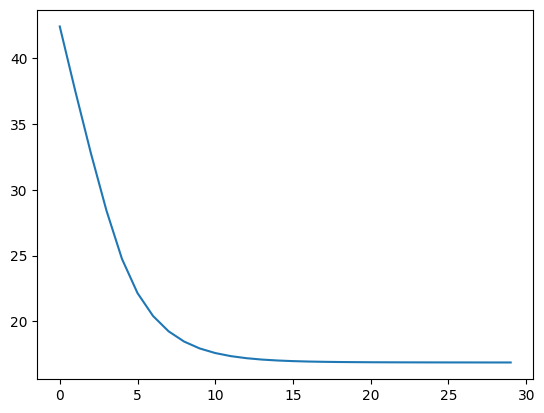

In [38]:
mini_batch_training(8)